# Perceptron and Activation Functions

**Author:** Phabel Antonio López Delgado, BSc.

This notebook introduces the perceptron, a fundamental building block of neural networks. We build a perceptron from scratch, evaluate the step activation function, and visualise common activation functions (sigmoid, tanh, ReLU) using synthetic data.

**Key Concepts Covered:**
- Perceptron decision boundary.
- Step function for binary classification.
- Activation functions: sigmoid, tanh, ReLU.
- Vectorised perceptron implementation.

**Key Techniques & Libraries:**
- `numpy` – numerical operations.
- `matplotlib` – visualisation.
- `sklearn.datasets` – synthetic data generation.

**Objective:**
To understand the mechanics of a single neuron, how it makes decisions, and the role of activation functions in introducing non‑linearity.

In [38]:
# Load libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Set seed for reproducibility (use 3 to match original)
np.random.seed(3)

## Step 1: Generate Synthetic Data

We generate a binary classification dataset using `make_classification` from scikit‑learn.

In [39]:
# Number of classes to generate
num_classes = 2

# Generate data
data, labels = make_classification(
    n_samples=10000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=5
)

# Split data by class
classes = [data[labels == i] for i in range(num_classes)]

print("Data shape:", data.shape)
print("Classes:", len(classes))

Data shape: (10000, 2)
Classes: 2


In [40]:
# Display first 150 labels
print(labels[1:150])

[0 1 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 0 1 1 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0
 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 0 0 0 1 1 1 1 1 0 1 1 0 1 1 1 0 0 1 0 0 0 0
 0 0 1 0 1 1 1 1 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1 1 1 0
 1 1 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 1 1
 1]


In [41]:
def plot_data(classes, ax=None, figsize=(5, 5)):
    """
    Visualise the synthetic data.

    Parameters:
        classes (list): list of arrays, each containing points of one class.
        ax (matplotlib.axes): axis to plot on (optional).
        figsize (tuple): figure size if ax is None.
    """
    if ax is None:
        _, axis = plt.subplots(figsize=figsize)
    else:
        axis = ax
    for i, c in enumerate(classes):
        axis.plot(c[:, 0], c[:, 1], '*', label=f'Class {i}')
    plt.legend()
    if ax is None:
        plt.show()
    return axis

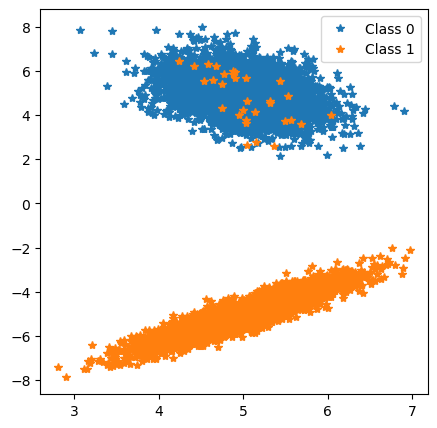

<Axes: >

In [42]:
# Visualise the data
plot_data(classes)

## 2. Perceptron Decision Boundary

A perceptron makes decisions using a linear decision boundary. We define functions to plot a separating line and classify new points.

In [43]:
def separating_line(w, b, x_range=(np.min(data[:, 0]), np.max(data[:, 0]))):
    """
    Generate points for a decision boundary line.

    Parameters:
        w (float): slope.
        b (float): intercept.
        x_range (tuple): min and max x values.

    Returns:
        x (array), y (array): points on the line.
    """
    x = np.linspace(x_range[0], x_range[1])
    y = w * x + b  # Slope-intercept form
    return x, y

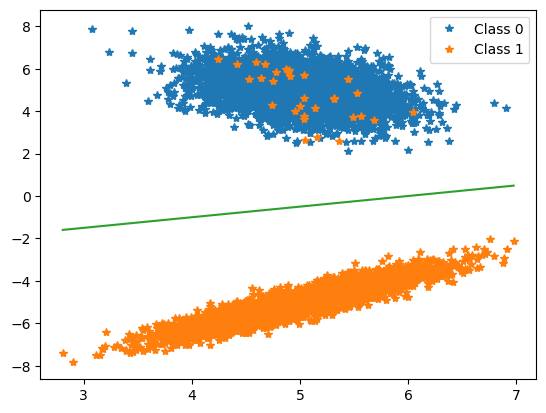

In [44]:
# Parameters: slope (w), intercept (b)
params = (0.5, -3)

_, ax = plt.subplots()
plot_data(classes, ax)
ax.plot(*separating_line(*params))
plt.show()

## 3. Classifying a New Point

We add a new point and determine its class using the step activation function.

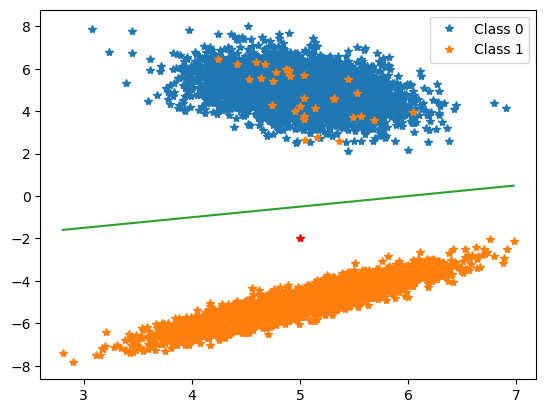

Which class does the new point belong to?


In [46]:
point = (5, -2)

_, ax = plt.subplots()
plot_data(classes, ax)
ax.plot(*separating_line(*params))
ax.plot(*point, 'r*')
plt.show()

print("Which class does the new point belong to?")

## 4: Classifying with the Step Function

We classify the new point using the step function, which outputs +1 or -1.

In [47]:
def classify(a, b, x, y):
    """Return the signed distance from the point to the line: y - a*x - b."""
    return y - a * x - b

def step_function(z):
    """Step activation function."""
    return z / np.abs(z)

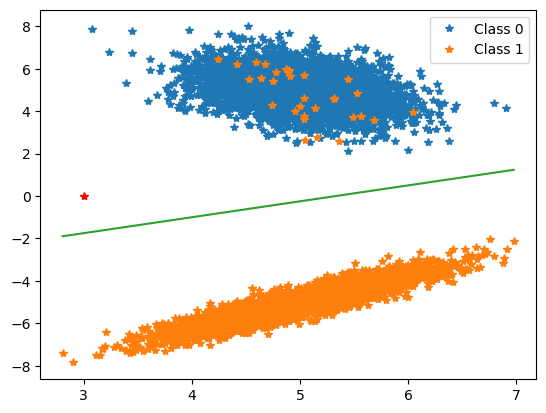

The point (3, 0) has classification value: 1.75
It belongs to class: 1 (1.0 for class 1, -1.0 for class 0)


In [48]:
# Define parameters and point
params = (0.75, -4)  # slope, intercept
point = (3, 0)       # x, y

_, ax = plt.subplots()
plot_data(classes, ax)
ax.plot(*separating_line(*params))
ax.plot(*point, 'r*')
plt.show()

clz = classify(params[0], params[1], point[0], point[1])
print(f"The point {point} has classification value: {clz}")

# Apply step function
predicted_class = step_function(clz)
print(f"It belongs to class: {predicted_class:.0f} (1.0 for class 1, -1.0 for class 0)")

## 5. Activation Functions

We implement and visualise three common activation functions:
- **Sigmoid** – outputs values between 0 and 1.
- **Tanh** – outputs values between -1 and 1.
- **ReLU** – outputs max(0, z).

These functions introduce non‑linearity, enabling neural networks to learn complex patterns.

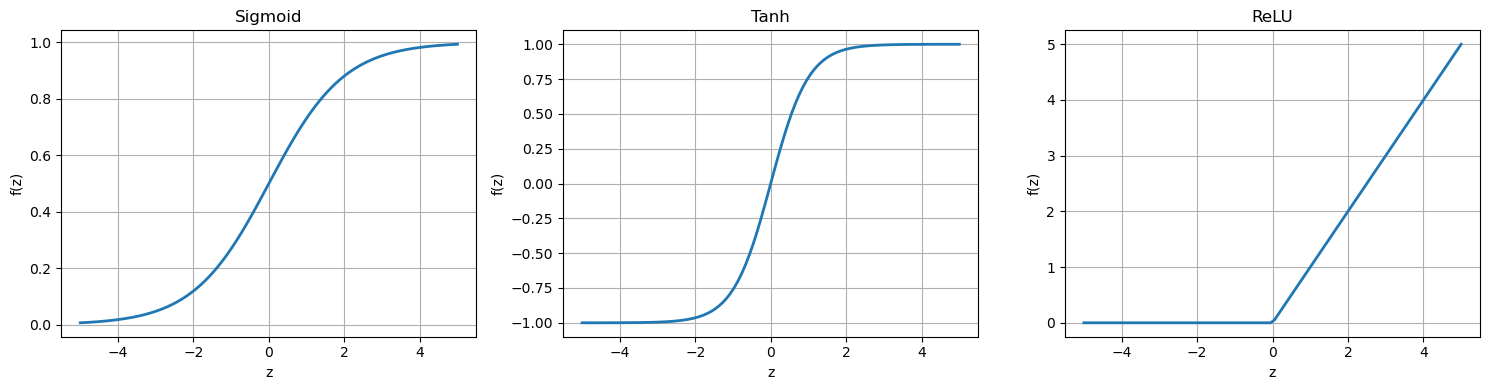

In [49]:
def sigmoid(z):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def tanh(z):
    """Hyperbolic tangent activation function."""
    return np.tanh(z)

def relu(z):
    """Rectified Linear Unit activation function."""
    return np.maximum(0, z)

# Visualise activation functions
z = np.linspace(-5, 5, 100)
functions = [sigmoid, tanh, relu]
titles = ['Sigmoid', 'Tanh', 'ReLU']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, func, title in zip(axes, functions, titles):
    ax.plot(z, func(z), linewidth=2)
    ax.grid(True)
    ax.set_title(title)
    ax.set_xlabel('z')
    ax.set_ylabel('f(z)')
plt.tight_layout()
plt.show()

## 6. Vectorised Perceptron Implementation

We implement the perceptron using matrix operations, which is efficient and extensible.

In [50]:
def generate_line_vectorised(W, x_range=(np.min(data[:, 0]), np.max(data[:, 0]))):
    """
    Generate decision boundary from weight vector W.

    Parameters:
        W (array): weight vector [w0, w1, w2] where w0 is bias.
        x_range (tuple): min and max x values.

    Returns:
        x (array), y (array): points on the decision boundary.
    """
    # W = [w0, w1, w2] represents w0 + w1*x + w2*y = 0
    # So y = -(w0 + w1*x) / w2
    ws = -(W / W[-1])[:2]  # w1/w2, w0/w2
    x = np.linspace(x_range[0], x_range[1])
    X = np.array([np.ones_like(x), x])
    return x, np.dot(ws.T, X)[0]

def visualise_data_vectorised(W=None, point=None, return_ax=False):
    """
    Visualise data, decision boundary, and a point.

    Parameters:
        W (array): weight vector.
        point (tuple): (x, y) point to mark.
        return_ax (bool): if True, return the axis object.

    Returns:
        ax (matplotlib.axes): axis (if return_ax is True).
    """
    _, ax = plt.subplots()
    plot_data(classes, ax)
    if W is not None:
        ax.plot(*generate_line_vectorised(W))
    if point is not None:
        ax.plot(point[0], point[1], 'r*')
    if return_ax:
        return ax
    else:
        plt.show()

def classifier_matrix(X, W, activation=relu):
    """
    Classify using vectorised perceptron.

    Parameters:
        X (array): input vector [1, x, y].
        W (array): weight vector [w0, w1, w2].
        activation (callable): activation function.

    Returns:
        array: activation output.
    """
    return activation(np.dot(W.T, X))

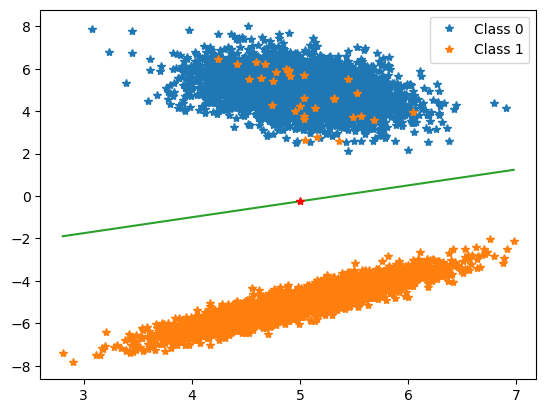

The point (5, -0.25) belongs to class: 0


In [51]:
# Parameters: y = a*x + b  ->  w0 + w1*x + w2*y = 0  with w0 = -b, w1 = -a, w2 = 1
a, b = 0.75, -4
point = (5, -0.25)

W = np.array([[-b],   # w0
              [-a],   # w1
              [1]])   # w2

X = np.array([[1],        # x0 (bias)
              [point[0]], # x1 (x)
              [point[1]]])# x2 (y)

visualise_data_vectorised(W, point)

prediction = classifier_matrix(X, W, activation=relu)
print(f"The point {point} belongs to class: {prediction[0, 0]:.0f}")

## Summary and Next Steps

**Accomplished:**
- Implemented a perceptron using a step activation function for binary classification.
- Visualised the decision boundary on synthetic data generated with `make_classification`.
- Demonstrated three common activation functions: sigmoid, tanh, and ReLU.
- Implemented a vectorised version of the perceptron for efficient computation.
- Tested the perceptron on a new point, showing correct classification.

**Key Results:**
- The perceptron classified the point (3, 0) as class 1 using the step function.
- The vectorised perceptron classified the point (5, -0.25) as class 0.
- The decision boundaries were correctly visualised for both implementations.

**Key Insights:**
- The perceptron is a linear classifier limited to linearly separable data.
- The step function gives a hard binary decision (+1 or -1).
- Activation functions like sigmoid, tanh, and ReLU introduce non‑linearity, which is essential for learning complex patterns in neural networks.
- Vectorisation makes the perceptron efficient and prepares the way for multi‑layer networks.

**Suggested Next Steps:**
1. **Implement the perceptron learning rule** – train the weights from data using gradient descent.
2. **Extend to multi‑class classification** – use one‑vs‑all or softmax.
3. **Build a multi‑layer perceptron (MLP)** – with backpropagation.
4. **Evaluate different activation functions** – on a real‑world dataset to compare performance.

**Reflection:**
This notebook provides a foundational understanding of artificial neurons, decision boundaries, and activation functions – the essential building blocks of neural networks. The step function illustrates the original perceptron, while modern activation functions introduce the non‑linearities that enable deep learning to tackle complex problems. The vectorised implementation demonstrates the efficiency of matrix operations, a key concept in modern deep learning frameworks.